In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


In [2]:
df = pd.read_csv('student-mat.csv', sep=';')

print(df.head())
print(df.shape)

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
(395, 33)


In [3]:
# Convert final marks into grade categories

def grade_category(score):

    if score >= 16:
        return 'A'

    elif score >= 14:
        return 'B'

    elif score >= 10:
        return 'C'

    else:
        return 'F'


# Create target column

df['final_grade'] = df['G3'].apply(grade_category)

print(df[['G3', 'final_grade']].head())

   G3 final_grade
0   6           F
1   6           F
2  10           C
3  15           B
4  10           C


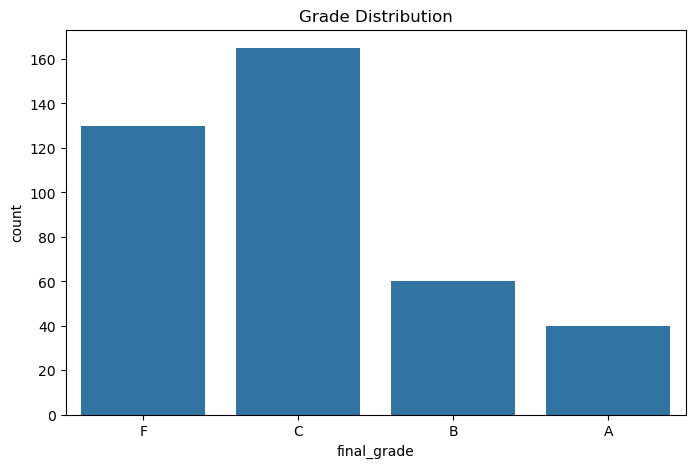

In [4]:
plt.figure(figsize=(8,5))

sns.countplot(x=df['final_grade'])

plt.title('Grade Distribution')
plt.show()

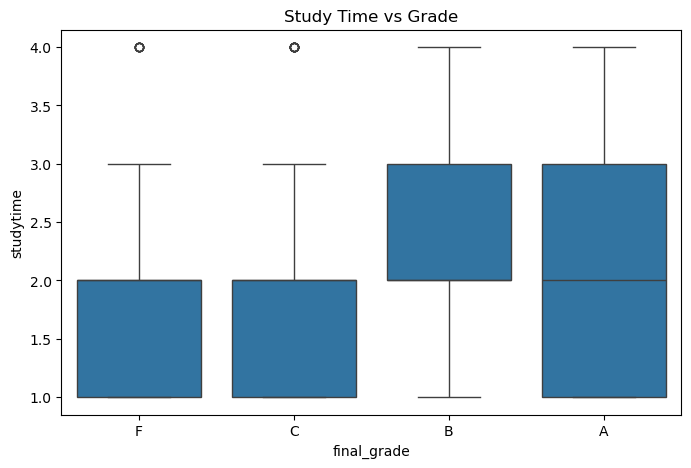

In [5]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['final_grade'], y=df['studytime'])

plt.title('Study Time vs Grade')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

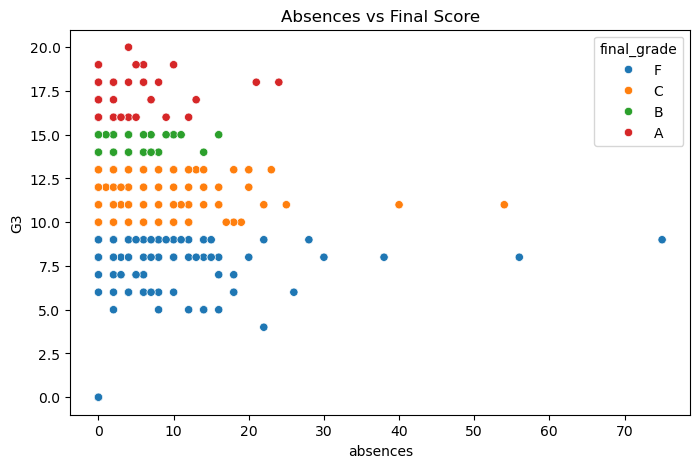

In [6]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['absences'],
    y=df['G3'],
    hue=df['final_grade']
)

plt.title('Absences vs Final Score')
plt.show

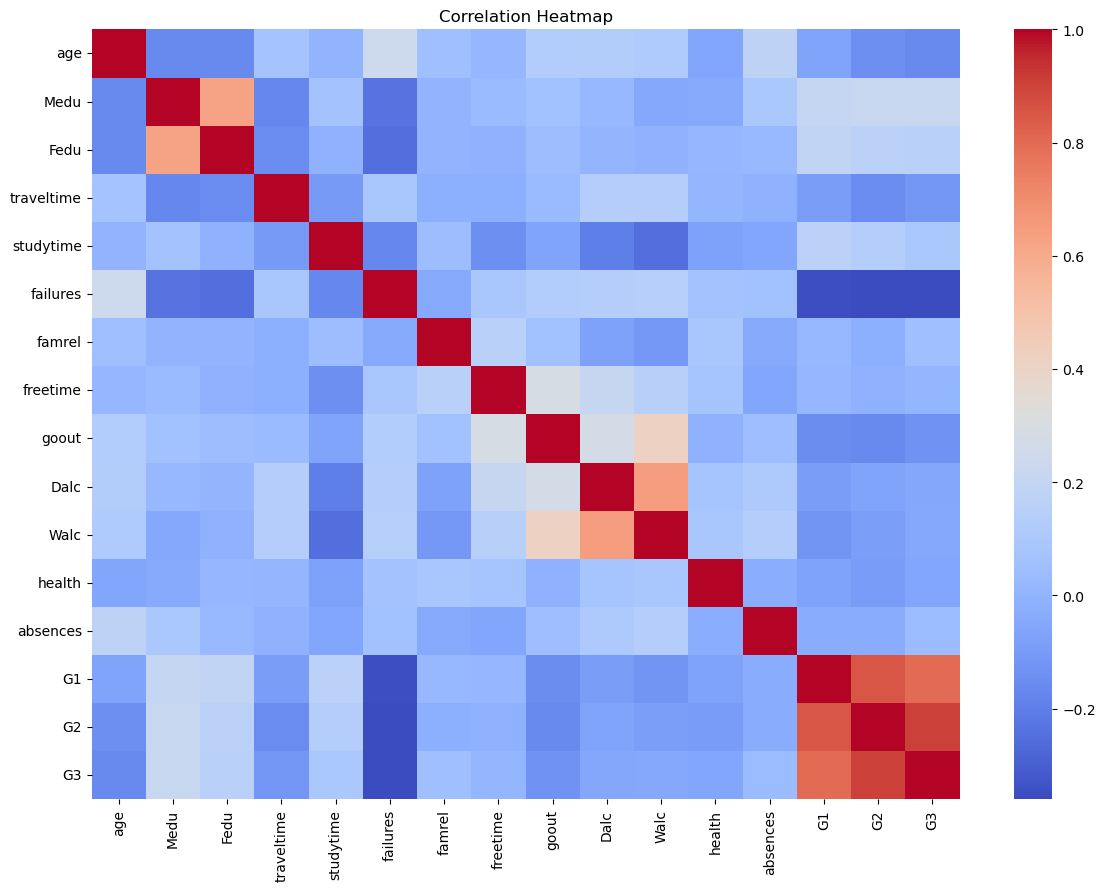

In [7]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))

sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

In [8]:
features = [
    'sex',
    'age',
    'studytime',
    'failures',
    'schoolsup',
    'famsup',
    'paid',
    'activities',
    'internet',
    'higher',
    'absences',
    'G1',
    'G2'
]

X = df[features]
y = df['final_grade']

In [9]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['A' 'B' 'C' 'F']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(316, 13)
(79, 13)


In [11]:
train_data = X_train.copy()
train_data['target'] = y_train

train_data.to_csv('train_data.csv', index=False)


test_data = X_test.copy()
test_data['target'] = y_test

test_data.to_csv('test_data.csv', index=False)

print('Train and Test data saved successfully')

Train and Test data saved successfully


In [12]:
categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(exclude='object').columns


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])


categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

In [13]:
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000))
])

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

In [14]:
decision_tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ))
])


decision_tree_model.fit(X_train, y_train)


decision_tree_predictions = decision_tree_model.predict(X_test)

In [15]:
random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=500,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42
    ))
])


random_forest_model.fit(X_train, y_train)


random_forest_predictions = random_forest_model.predict(X_test)

In [16]:
svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf'))
])

svm_model.fit(X_train, y_train)

svm_predictions = svm_model.predict(X_test)

In [17]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

if hasattr(X_train_processed, 'toarray'):
    X_train_processed = X_train_processed.toarray()

if hasattr(X_test_processed, 'toarray'):
    X_test_processed = X_test_processed.toarray()


naive_bayes_model = GaussianNB()

naive_bayes_model.fit(X_train_processed, y_train)

naive_bayes_predictions = naive_bayes_model.predict(X_test_processed)

In [18]:
models = {
    'Logistic Regression': logistic_predictions,
    'Decision Tree': decision_tree_predictions,
    'Random Forest': random_forest_predictions,
    'SVM': svm_predictions,
    'Naive Bayes': naive_bayes_predictions
}

results = []

for model_name, predictions in models.items():

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        average='weighted'
    )
    recall = recall_score(
        y_test,
        predictions,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        predictions,
        average='weighted'
    )

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])
    results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.810127   0.807578  0.810127  0.807966
1        Decision Tree  0.784810   0.789154  0.784810  0.781979
2        Random Forest  0.848101   0.848957  0.848101  0.847000
3                  SVM  0.810127   0.812345  0.810127  0.809086
4          Naive Bayes  0.531646   0.619686  0.531646  0.497416


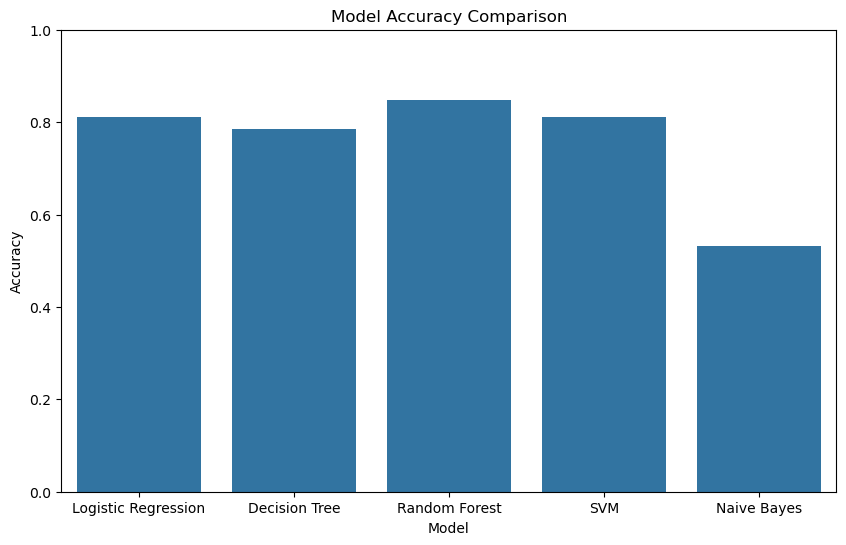

In [19]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_df
)

plt.title('Model Accuracy Comparison')
plt.ylim(0,1)
plt.show()

In [20]:
print(classification_report(
    y_test,
    random_forest_predictions
))

              precision    recall  f1-score   support

           0       0.86      0.75      0.80         8
           1       0.82      0.75      0.78        12
           2       0.88      0.85      0.86        33
           3       0.83      0.92      0.87        26

    accuracy                           0.85        79
   macro avg       0.84      0.82      0.83        79
weighted avg       0.85      0.85      0.85        79



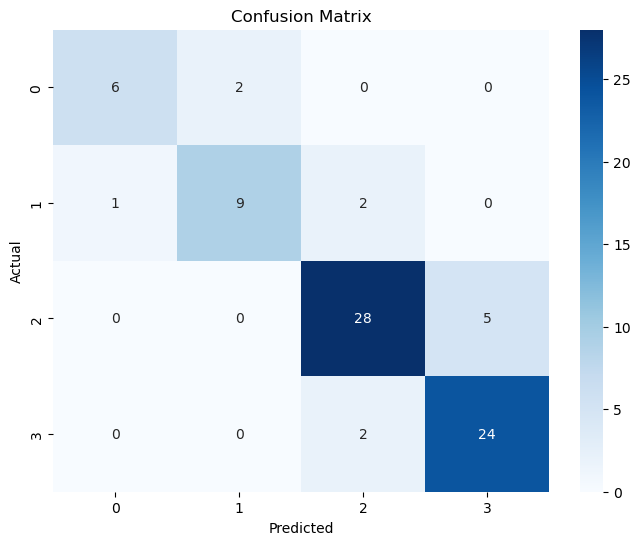

In [21]:
cm = confusion_matrix(y_test, random_forest_predictions)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [22]:
joblib.dump(random_forest_model, 'model.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

print('Model saved successfully')

Model saved successfully


In [23]:
loaded_model = joblib.load('model.pkl')
loaded_encoder = joblib.load('label_encoder.pkl')

In [24]:
new_student = pd.DataFrame({
    'sex': ['F'],
    'age': [17],
    'studytime': [3],
    'failures': [0],
    'schoolsup': ['yes'],
    'famsup': ['yes'],
    'paid': ['no'],
    'activities': ['yes'],
    'internet': ['yes'],
    'higher': ['yes'],
    'absences': [4],
    'G1': [15],
    'G2': [16]
})


prediction = loaded_model.predict(new_student)

predicted_grade = loaded_encoder.inverse_transform(prediction)

print('Predicted Grade:', predicted_grade[0])

Predicted Grade: A
